# Teacher + Student Comparison (6 Scenarios)

This notebook compares six different scenarios:
- Teacher1 baseline (HybridCNNViTBase) alone
- Teacher2 advanced (AdvancedHybridModel, Adv_Idea_5_SpectralNorm) alone
- Gate-based ensemble of the two teachers (Gate1)
- Equal-weight (no gate) ensemble of the two teachers
- **Teachers + Student with Gate2 (from trained checkpoint)**
- **Teachers + Student with Equal Weight (no gate, inference only)**

Metrics and split follow the original training notebooks (80/10/10).
Results are reported on validation and test.

In [1]:
# 1) Imports
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, cohen_kappa_score
 )

from models.hybrid_cnn_vit_base import HybridCNNViTBase
from models.advanced_hybrid_models import AdvancedHybridModel, ContrastiveLoss, PrototypicalLoss
from advanced_model_configs import get_advanced_model_config
from dataset_loader import get_data_loaders

print('Imports ready')

Imports ready


c:\Users\PC1\anaconda3\envs\mrt_torch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 2) Config
SEED = 42
BATCH_SIZE = 16
DATASET_PATH = 'APTOS2019'

RUN_TRAINING = True  # set False to reuse existing checkpoints in RESULTS_ROOT

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RESULTS_ROOT = Path('results/teacher_student_compare_retrain')
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

BASELINE_MODEL_NAME = 'Teacher1_Baseline'
ADV_MODEL_NAME = 'Teacher2_Advanced_SpectralNorm'
GATE_MODEL_NAME = 'Teachers_Gated_Ensemble'

BASELINE_EPOCHS = 110
BASELINE_LR = 1e-3
BASELINE_PATIENCE = 15

ADV_EPOCHS = 100
ADV_LR = 1e-4
ADV_PATIENCE = 15

GATE_EPOCHS = 120
GATE_LR = 1e-4
GATE_PATIENCE = 18
GATE_LAMBDA_START = 1.5
GATE_LAMBDA_END = 0.6
GATE_MARGIN_START = 0.02
GATE_MARGIN_END = 0.005
GATE_ENTROPY_BETA = 0.02

BASELINE_CONFIG = {
    'fusion_method': 'gate',
    'use_uncertainty_refinement': False,
    'use_ordinal_head': False,
    'use_prototype_memory': False
}
ADV_CONFIG_NAME = 'Adv_Idea_5_SpectralNorm'

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print('Device:', device)
print('Results root:', RESULTS_ROOT)

Device: cuda
Results root: results\teacher_student_compare_retrain


In [3]:
# 3) Data loaders
train_loader, val_loader, test_loader, class_weights, split_data = get_data_loaders(
    dataset_path=DATASET_PATH,
    batch_size=BATCH_SIZE,
)

X_train, y_train, X_val, y_val, X_test, y_test = split_data
total = len(X_train) + len(X_val) + len(X_test)
print('Train:', len(X_train), f'({len(X_train)/total*100:.1f}%)')
print('Val:', len(X_val), f'({len(X_val)/total*100:.1f}%)')
print('Test:', len(X_test), f'({len(X_test)/total*100:.1f}%)')

Total training samples: 3662
Class distribution:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

--- Öngörülen Veri Dağılımı ---
Eğitim (Train) : ~2929 örnek (%80.0)
Doğrulama (Val): ~366 örnek (%10.0)
Test (Test)    : ~366 örnek (%10.0)
-------------------------------
Resimler diske yüklenmeye başlıyor, lütfen bekleyin...

Loaded 100/3662 images
Loaded 200/3662 images
Loaded 300/3662 images
Loaded 400/3662 images
Loaded 500/3662 images
Loaded 600/3662 images
Loaded 700/3662 images
Loaded 800/3662 images
Loaded 900/3662 images
Loaded 1000/3662 images
Loaded 1100/3662 images
Loaded 1200/3662 images
Loaded 1300/3662 images
Loaded 1400/3662 images
Loaded 1500/3662 images
Loaded 1600/3662 images
Loaded 1700/3662 images
Loaded 1800/3662 images
Loaded 1900/3662 images
Loaded 2000/3662 images
Loaded 2100/3662 images
Loaded 2200/3662 images
Loaded 2300/3662 images
Loaded 2400/3662 images
Loaded 2500/3662 images
Loaded 2600/3662 images
Loaded 2700/3662 ima

In [4]:
# 4) Metric helpers
def _mean_specificity(y_true, y_pred, num_classes=5):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    specs = []
    for c in range(num_classes):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)
        denom = tn + fp
        specs.append((tn / denom) if denom > 0 else 0.0)
    return float(np.mean(specs))

def compute_full_metrics(y_true, y_pred, y_prob, num_classes=5):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_prob = np.asarray(y_prob)

    metrics = {}
    metrics['accuracy'] = float(accuracy_score(y_true, y_pred))
    metrics['precision_macro'] = float(precision_score(y_true, y_pred, average='macro', zero_division=0))
    metrics['recall_macro'] = float(recall_score(y_true, y_pred, average='macro', zero_division=0))
    metrics['f1_macro'] = float(f1_score(y_true, y_pred, average='macro', zero_division=0))
    metrics['precision_weighted'] = float(precision_score(y_true, y_pred, average='weighted', zero_division=0))
    metrics['recall_weighted'] = float(recall_score(y_true, y_pred, average='weighted', zero_division=0))
    metrics['f1_weighted'] = float(f1_score(y_true, y_pred, average='weighted', zero_division=0))
    metrics['specificity'] = _mean_specificity(y_true, y_pred, num_classes=num_classes)
    metrics['qwk'] = float(cohen_kappa_score(y_true, y_pred, weights='quadratic'))
    try:
        metrics['roc_auc'] = float(roc_auc_score(y_true, y_prob, multi_class='ovr', average='weighted'))
    except Exception:
        metrics['roc_auc'] = 0.0
    return metrics

def class_weight_tensor_from_dict(class_weights_dict, device, n_classes=5):
    if isinstance(class_weights_dict, dict):
        arr = [float(class_weights_dict.get(i, 1.0)) for i in range(n_classes)]
    else:
        arr = [1.0] * n_classes
    return torch.tensor(arr, dtype=torch.float32, device=device)

print('Metric helpers ready')

Metric helpers ready


In [5]:
# 5) Model definitions
class ImprovedBaselineAnchoredEnsemble(nn.Module):
    """
    Gate-based ensemble over two fixed teachers:
    - Baseline teacher (frozen)
    - Advanced teacher (frozen)
    """
    def __init__(self, baseline_model: nn.Module, adv_model: nn.Module, gate_dropout: float = 0.1):
        super().__init__()
        self.baseline_model = baseline_model
        self.adv_model = adv_model

        for p in self.baseline_model.parameters():
            p.requires_grad = False
        for p in self.adv_model.parameters():
            p.requires_grad = False

        self.baseline_model.eval()
        self.adv_model.eval()

        # gate input: p_base(5) + p_adv(5) + ent_base(1) + ent_adv(1) + conf_gap(1) = 13
        self.gate = nn.Sequential(
            nn.Linear(13, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(gate_dropout),
            nn.Linear(64, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    @staticmethod
    def _entropy(p: torch.Tensor) -> torch.Tensor:
        p = p.clamp_min(1e-8)
        return -(p * torch.log(p)).sum(dim=1, keepdim=True)

    def forward(self, x):
        with torch.no_grad():
            base_logits = self.baseline_model(x)
            p_base = F.softmax(base_logits, dim=1)

        adv_logits, adv_extra = self.adv_model(x)
        p_adv = F.softmax(adv_logits, dim=1)

        ent_base = self._entropy(p_base)
        ent_adv = self._entropy(p_adv)
        conf_gap = (p_base.max(dim=1, keepdim=True).values - p_adv.max(dim=1, keepdim=True).values).abs()

        gate_in = torch.cat([p_base, p_adv, ent_base, ent_adv, conf_gap], dim=1)
        g = self.gate(gate_in)
        p_final = (1.0 - g) * p_base + g * p_adv
        log_p_final = torch.log(p_final.clamp_min(1e-8))

        extra = {
            'gate': g,
            'p_base': p_base,
            'p_adv': p_adv,
            'adv_extra': adv_extra,
        }
        return log_p_final, extra

def get_logits(model, x):
    out = model(x)
    if isinstance(out, (tuple, list)):
        return out[0]
    return out

print('Model definitions ready')

Model definitions ready


In [ ]:
# 5b) Student Model Definition (for inference only)
class LiteCNNViTStudent(nn.Module):
    """Low-parameter CNN+ViT student for low-data setup."""
    def __init__(self, num_classes: int = 5, embed_dim: int = 128):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
        )

        self.patch_embed = nn.Conv2d(3, embed_dim, kernel_size=16, stride=16)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=4,
            dim_feedforward=256,
            dropout=0.1,
            batch_first=True
        )
        self.vit_encoder = nn.TransformerEncoder(enc_layer, num_layers=2)
        self.vit_fc = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
        )

        self.fusion = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        cnn_feat = self.cnn(x)
        tokens = self.patch_embed(x).flatten(2).transpose(1, 2)
        tokens = self.vit_encoder(tokens)
        vit_feat = self.vit_fc(tokens.mean(dim=1))
        fused = torch.cat([cnn_feat, vit_feat], dim=1)
        logits = self.fusion(fused)
        return logits, {'student_feat': fused}

class HeavyTeacherEnsemble(nn.Module):
    """Teacher ensemble with Gate1 (baseline + advanced)."""
    def __init__(self, baseline_model: nn.Module, adv_model: nn.Module, gate_dropout: float = 0.1):
        super().__init__()
        self.baseline_model = baseline_model
        self.adv_model = adv_model

        for p in self.baseline_model.parameters():
            p.requires_grad = False
        for p in self.adv_model.parameters():
            p.requires_grad = False

        self.baseline_model.eval()
        self.adv_model.eval()

        self.gate = nn.Sequential(
            nn.Linear(13, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(gate_dropout),
            nn.Linear(64, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    @staticmethod
    def _entropy(p: torch.Tensor) -> torch.Tensor:
        p = p.clamp_min(1e-8)
        return -(p * torch.log(p)).sum(dim=1, keepdim=True)

    def forward(self, x):
        with torch.no_grad():
            base_logits = self.baseline_model(x)
            p_base = F.softmax(base_logits, dim=1)

        adv_logits, _ = self.adv_model(x)
        p_adv = F.softmax(adv_logits, dim=1)

        ent_base = self._entropy(p_base)
        ent_adv = self._entropy(p_adv)
        conf_gap = (p_base.max(dim=1, keepdim=True).values - p_adv.max(dim=1, keepdim=True).values).abs()

        gate_in = torch.cat([p_base, p_adv, ent_base, ent_adv, conf_gap], dim=1)
        g = self.gate(gate_in)
        p_final = (1.0 - g) * p_base + g * p_adv
        z_teacher = torch.log(p_final.clamp_min(1e-8))
        return z_teacher, {'gate': g, 'p_teacher': p_final}

class ResidualTeacherStudentModel(nn.Module):
    """Teacher-Student with Gate2 (residual mixing + conflict brake)."""
    def __init__(
        self,
        teacher_model: nn.Module,
        student_model: nn.Module,
        residual_scale: float = 0.75,
        use_conflict_brake: bool = True,
        conflict_threshold: float = 0.80,
        conflict_gmax: float = 0.70
    ):
        super().__init__()
        self.teacher_model = teacher_model
        self.student_model = student_model
        self.residual_scale = float(residual_scale)
        self.use_conflict_brake = bool(use_conflict_brake)
        self.conflict_threshold = float(conflict_threshold)
        self.conflict_gmax = float(conflict_gmax)

        for p in self.teacher_model.parameters():
            p.requires_grad = False

        self.gate = nn.Sequential(
            nn.Linear(13, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    @staticmethod
    def _entropy(p: torch.Tensor) -> torch.Tensor:
        p = p.clamp_min(1e-8)
        return -(p * torch.log(p)).sum(dim=1, keepdim=True)

    def forward(self, x):
        with torch.no_grad():
            z_teacher, _ = self.teacher_model(x)
            p_teacher = F.softmax(z_teacher, dim=1)

        z_student, student_extra = self.student_model(x)
        p_student = F.softmax(z_student, dim=1)

        ent_t = self._entropy(p_teacher)
        ent_s = self._entropy(p_student)
        conf_gap = (p_teacher.max(dim=1, keepdim=True).values - p_student.max(dim=1, keepdim=True).values).abs()
        g_in = torch.cat([p_teacher, p_student, ent_t, ent_s, conf_gap], dim=1)
        g = self.gate(g_in)

        if self.use_conflict_brake:
            teacher_conf, teacher_pred = p_teacher.max(dim=1)
            student_pred = p_student.argmax(dim=1)
            conflict_mask = (teacher_conf > self.conflict_threshold) & (teacher_pred != student_pred)
            if conflict_mask.any():
                dynamic_cap = (self.conflict_gmax * (1.0 - teacher_conf)).unsqueeze(1)
                g_limited = torch.minimum(g, dynamic_cap)
                g = torch.where(conflict_mask.unsqueeze(1), g_limited, g)

        delta = z_student - z_student.mean(dim=1, keepdim=True)
        z_final = z_teacher + self.residual_scale * g * delta

        extra = {
            'gate': g,
            'z_teacher': z_teacher,
            'z_student': z_student,
            'p_teacher': p_teacher,
            'p_student': p_student,
            'student_extra': student_extra,
        }
        return z_final, extra

print('Student model definitions ready')

In [6]:
# 6) Trainers (resume-safe)
class BaselineTrainer:
    def __init__(self, model_name: str, config: dict, num_epochs=80, lr=1e-3):
        self.model_name = model_name
        self.config = config
        self.num_epochs = int(num_epochs)
        self.device = device

        self.model_dir = RESULTS_ROOT / model_name
        self.model_dir.mkdir(parents=True, exist_ok=True)
        self.ckpt_path = self.model_dir / 'checkpoint_current.pth'
        self.best_path = self.model_dir / 'best_model.pth'
        self.hist_path = self.model_dir / 'training_history.json'
        self.metrics_path = self.model_dir / 'test_metrics.json'

        self.model = HybridCNNViTBase(num_classes=5, config=config).to(self.device)
        self.optimizer = optim.AdamW(self.model.parameters(), lr=lr, weight_decay=1e-4)
        self.scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(self.optimizer, T_0=10, T_mult=2)
        self.class_w = class_weight_tensor_from_dict(class_weights, self.device, n_classes=5)
        self.ce = nn.CrossEntropyLoss(weight=self.class_w)

        self.history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_qwk': []}
        self.best_qwk = -1e9
        self.start_epoch = 0
        self._load_checkpoint()

    def _load_checkpoint(self):
        if self.ckpt_path.exists():
            ckpt = torch.load(self.ckpt_path, map_location=self.device)
            self.model.load_state_dict(ckpt['model_state'])
            self.optimizer.load_state_dict(ckpt['optimizer_state'])
            self.scheduler.load_state_dict(ckpt['scheduler_state'])
            self.history = ckpt['history']
            self.best_qwk = ckpt['best_qwk']
            self.start_epoch = int(ckpt['epoch']) + 1
            print(f'[Baseline] Resume epoch {self.start_epoch}')

    def _save_checkpoint(self, epoch):
        ckpt = {
            'epoch': epoch,
            'model_state': self.model.state_dict(),
            'optimizer_state': self.optimizer.state_dict(),
            'scheduler_state': self.scheduler.state_dict(),
            'history': self.history,
            'best_qwk': self.best_qwk
        }
        torch.save(ckpt, self.ckpt_path)

    def train_epoch(self, loader):
        self.model.train()
        total = 0.0
        for images, labels in loader:
            images = images.to(self.device)
            labels = labels.to(self.device)
            y = labels.argmax(1) if labels.ndim > 1 else labels

            self.optimizer.zero_grad()
            logits = self.model(images)
            loss = self.ce(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()
            total += float(loss.item())
        return total / max(1, len(loader))

    def validate(self, loader):
        self.model.eval()
        total = 0.0
        y_true, y_pred, y_prob = [], [], []
        with torch.no_grad():
            for images, labels in loader:
                images = images.to(self.device)
                labels = labels.to(self.device)
                y = labels.argmax(1) if labels.ndim > 1 else labels

                logits = self.model(images)
                loss = self.ce(logits, y)
                total += float(loss.item())

                prob = F.softmax(logits, dim=1)
                pred = prob.argmax(1)
                y_true.extend(y.detach().cpu().numpy().tolist())
                y_pred.extend(pred.detach().cpu().numpy().tolist())
                y_prob.extend(prob.detach().cpu().numpy().tolist())

        val_loss = total / max(1, len(loader))
        m = compute_full_metrics(y_true, y_pred, y_prob, num_classes=5)
        return val_loss, m

    def fit(self, train_loader, val_loader, patience=15):
        wait = 0
        for epoch in range(self.start_epoch, self.num_epochs):
            tr_loss = self.train_epoch(train_loader)
            val_loss, vm = self.validate(val_loader)

            self.history['train_loss'].append(tr_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(vm['accuracy'])
            self.history['val_qwk'].append(vm['qwk'])

            self._save_checkpoint(epoch)

            if vm['qwk'] > self.best_qwk:
                self.best_qwk = vm['qwk']
                torch.save(self.model.state_dict(), self.best_path)
                wait = 0
            else:
                wait += 1

            self.scheduler.step()
            print(f"[Baseline] Epoch {epoch+1:03d} | tr={tr_loss:.4f} | val={val_loss:.4f} | acc={vm['accuracy']:.4f} | qwk={vm['qwk']:.4f}")

            if wait >= patience:
                print(f'[Baseline] Early stopping at epoch {epoch+1}')
                break

        with open(self.hist_path, 'w', encoding='utf-8') as f:
            json.dump(self.history, f, indent=2)

    def load_best(self):
        if self.best_path.exists():
            self.model.load_state_dict(torch.load(self.best_path, map_location=self.device))
        return self.model

    def evaluate_test(self, test_loader):
        self.load_best()
        self.model.eval()
        y_true, y_pred, y_prob = [], [], []
        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(self.device)
                labels = labels.to(self.device)
                y = labels.argmax(1) if labels.ndim > 1 else labels

                logits = self.model(images)
                prob = F.softmax(logits, dim=1)
                pred = prob.argmax(1)
                y_true.extend(y.detach().cpu().numpy().tolist())
                y_pred.extend(pred.detach().cpu().numpy().tolist())
                y_prob.extend(prob.detach().cpu().numpy().tolist())

        m = compute_full_metrics(y_true, y_pred, y_prob, num_classes=5)
        result = {'model_name': self.model_name, **m}
        with open(self.metrics_path, 'w', encoding='utf-8') as f:
            json.dump(result, f, indent=2)
        return result


class AdvancedModelTrainer:
    def __init__(self, model_name: str, config: dict, num_epochs=100, learning_rate=1e-4):
        self.model_name = model_name
        self.config = config
        self.device = device
        self.num_epochs = int(num_epochs)

        self.model_dir = RESULTS_ROOT / model_name
        self.model_dir.mkdir(parents=True, exist_ok=True)
        self.ckpt_path = self.model_dir / 'checkpoint_current.pth'
        self.best_path = self.model_dir / 'best_model.pth'
        self.hist_path = self.model_dir / 'training_history.json'
        self.metrics_path = self.model_dir / 'test_metrics.json'

        self.model = AdvancedHybridModel(num_classes=5, config=config).to(device)
        self.optimizer = optim.AdamW(self.model.parameters(), lr=learning_rate, weight_decay=1e-4)
        self.scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(self.optimizer, T_0=10, T_mult=2)
        self.class_w = class_weight_tensor_from_dict(class_weights, self.device, n_classes=5)
        self.ce = nn.CrossEntropyLoss(weight=self.class_w)

        self.aux_loss_fns = {}
        aux_cfg = self.config.get('auxiliary_losses', {})
        for aux_name, aux_params in aux_cfg.items():
            aux_type = aux_params.get('type', '')
            if aux_type == 'contrastive':
                self.aux_loss_fns[aux_name] = (ContrastiveLoss(temperature=0.1), float(aux_params.get('weight', 0.3)))
            elif aux_type == 'prototypical':
                self.aux_loss_fns[aux_name] = (PrototypicalLoss(), float(aux_params.get('weight', 0.5)))

        self.history = {
            'train_loss': [],
            'val_loss': [],
            'val_acc': [],
            'val_qwk': []
        }
        self.best_qwk = -1e9
        self.start_epoch = 0
        self._load_checkpoint()

    def _load_checkpoint(self):
        if self.ckpt_path.exists():
            ckpt = torch.load(self.ckpt_path, map_location=self.device)
            self.model.load_state_dict(ckpt['model_state'])
            self.optimizer.load_state_dict(ckpt['optimizer_state'])
            self.scheduler.load_state_dict(ckpt['scheduler_state'])
            self.history = ckpt['history']
            self.best_qwk = ckpt['best_qwk']
            self.start_epoch = int(ckpt['epoch']) + 1
            print(f'[Advanced] Resume epoch {self.start_epoch}, best QWK={self.best_qwk:.4f}')

    def _save_checkpoint(self, epoch):
        ckpt = {
            'epoch': epoch,
            'model_state': self.model.state_dict(),
            'optimizer_state': self.optimizer.state_dict(),
            'scheduler_state': self.scheduler.state_dict(),
            'history': self.history,
            'best_qwk': self.best_qwk
        }
        torch.save(ckpt, self.ckpt_path)

    def _calc_aux_losses(self, extra_outputs, labels_idx):
        aux_total = torch.tensor(0.0, device=self.device)
        for aux_name, (loss_fn, w) in self.aux_loss_fns.items():
            if aux_name == 'contrastive' and 'cnn_proj' in extra_outputs and 'vit_proj' in extra_outputs:
                aux_total = aux_total + w * loss_fn(extra_outputs['cnn_proj'], extra_outputs['vit_proj'], labels_idx)
            elif aux_name == 'prototypical' and 'final_feat' in extra_outputs and 'prototypes' in extra_outputs:
                aux_total = aux_total + w * loss_fn(extra_outputs['final_feat'], extra_outputs['prototypes'], labels_idx)
        return aux_total

    def train_epoch(self, loader):
        self.model.train()
        total = 0.0
        for images, labels in loader:
            images = images.to(self.device)
            labels = labels.to(self.device)
            y = labels.argmax(1) if labels.ndim > 1 else labels

            self.optimizer.zero_grad()
            logits, extra = self.model(images)
            loss_main = self.ce(logits, y)
            loss_aux = self._calc_aux_losses(extra, y)
            loss = loss_main + loss_aux
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()
            total += float(loss.item())
        return total / max(1, len(loader))

    def validate(self, loader):
        self.model.eval()
        total = 0.0
        y_true, y_pred, y_prob = [], [], []
        with torch.no_grad():
            for images, labels in loader:
                images = images.to(self.device)
                labels = labels.to(self.device)
                y = labels.argmax(1) if labels.ndim > 1 else labels

                logits, _ = self.model(images)
                loss = self.ce(logits, y)
                total += float(loss.item())
                prob = F.softmax(logits, dim=1)
                pred = prob.argmax(1)
                y_true.extend(y.detach().cpu().numpy().tolist())
                y_pred.extend(pred.detach().cpu().numpy().tolist())
                y_prob.extend(prob.detach().cpu().numpy().tolist())

        val_loss = total / max(1, len(loader))
        m = compute_full_metrics(y_true, y_pred, y_prob, num_classes=5)
        return val_loss, m

    def fit(self, train_loader, val_loader, patience=15):
        wait = 0
        for epoch in range(self.start_epoch, self.num_epochs):
            tr_loss = self.train_epoch(train_loader)
            val_loss, vm = self.validate(val_loader)

            self.history['train_loss'].append(tr_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(vm['accuracy'])
            self.history['val_qwk'].append(vm['qwk'])

            self._save_checkpoint(epoch)

            if vm['qwk'] > self.best_qwk:
                self.best_qwk = vm['qwk']
                torch.save(self.model.state_dict(), self.best_path)
                wait = 0
            else:
                wait += 1

            self.scheduler.step()
            print(f"[Advanced] Epoch {epoch+1:03d} | tr={tr_loss:.4f} | val={val_loss:.4f} | acc={vm['accuracy']:.4f} | qwk={vm['qwk']:.4f}")

            if wait >= patience:
                print(f'[Advanced] Early stopping at epoch {epoch+1}')
                break

        with open(self.hist_path, 'w', encoding='utf-8') as f:
            json.dump(self.history, f, indent=2)

    def load_best(self):
        if self.best_path.exists():
            self.model.load_state_dict(torch.load(self.best_path, map_location=self.device))
        return self.model

    def evaluate_test(self, test_loader):
        self.load_best()
        self.model.eval()
        y_true, y_pred, y_prob = [], [], []
        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(self.device)
                labels = labels.to(self.device)
                y = labels.argmax(1) if labels.ndim > 1 else labels

                logits, _ = self.model(images)
                prob = F.softmax(logits, dim=1)
                pred = prob.argmax(1)
                y_true.extend(y.detach().cpu().numpy().tolist())
                y_pred.extend(pred.detach().cpu().numpy().tolist())
                y_prob.extend(prob.detach().cpu().numpy().tolist())

        m = compute_full_metrics(y_true, y_pred, y_prob, num_classes=5)
        result = {'model_name': self.model_name, **m}
        with open(self.metrics_path, 'w', encoding='utf-8') as f:
            json.dump(result, f, indent=2)
        return result


class GateEnsembleTrainer:
    def __init__(self, model_name: str, baseline_model: nn.Module, adv_model: nn.Module, num_epochs=120, lr=1e-4,
                 lambda_start=1.5, lambda_end=0.6, margin_start=0.02, margin_end=0.005, gate_entropy_beta=0.02):
        self.model_name = model_name
        self.num_epochs = int(num_epochs)
        self.device = device

        self.lambda_start = float(lambda_start)
        self.lambda_end = float(lambda_end)
        self.margin_start = float(margin_start)
        self.margin_end = float(margin_end)
        self.gate_entropy_beta = float(gate_entropy_beta)

        self.model_dir = RESULTS_ROOT / model_name
        self.model_dir.mkdir(parents=True, exist_ok=True)
        self.ckpt_path = self.model_dir / 'checkpoint_current.pth'
        self.best_path = self.model_dir / 'best_model.pth'
        self.hist_path = self.model_dir / 'training_history.json'
        self.metrics_path = self.model_dir / 'test_metrics.json'

        self.model = ImprovedBaselineAnchoredEnsemble(baseline_model, adv_model).to(self.device)
        trainable_params = [p for p in self.model.parameters() if p.requires_grad]
        self.optimizer = optim.AdamW(trainable_params, lr=lr, weight_decay=1e-4)
        self.scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(self.optimizer, T_0=10, T_mult=2)
        self.class_w = class_weight_tensor_from_dict(class_weights, self.device, n_classes=5)
        self.nll_sample = nn.NLLLoss(weight=self.class_w, reduction='none')
        self.nll_mean = nn.NLLLoss(weight=self.class_w)

        self.history = {
            'train_loss': [],
            'val_loss': [],
            'val_acc': [],
            'val_qwk': [],
            'gate_mean': [],
            'lambda_noninf': [],
            'margin_noninf': []
        }
        self.best_qwk = -1e9
        self.start_epoch = 0
        self._load_checkpoint()

    def _load_checkpoint(self):
        if self.ckpt_path.exists():
            ckpt = torch.load(self.ckpt_path, map_location=self.device)
            self.model.load_state_dict(ckpt['model_state'])
            self.optimizer.load_state_dict(ckpt['optimizer_state'])
            self.scheduler.load_state_dict(ckpt['scheduler_state'])
            self.history = ckpt['history']
            self.best_qwk = ckpt['best_qwk']
            self.start_epoch = int(ckpt['epoch']) + 1
            print(f'[Gate] Resume epoch {self.start_epoch}')

    def _save_checkpoint(self, epoch):
        ckpt = {
            'epoch': epoch,
            'model_state': self.model.state_dict(),
            'optimizer_state': self.optimizer.state_dict(),
            'scheduler_state': self.scheduler.state_dict(),
            'history': self.history,
            'best_qwk': self.best_qwk
        }
        torch.save(ckpt, self.ckpt_path)

    def _schedule_noninf(self, epoch: int):
        if self.num_epochs <= 1:
            return self.lambda_end, self.margin_end
        progress = float(epoch) / float(self.num_epochs - 1)
        cur_lambda = self.lambda_start + progress * (self.lambda_end - self.lambda_start)
        cur_margin = self.margin_start + progress * (self.margin_end - self.margin_start)
        return float(cur_lambda), float(cur_margin)

    def train_epoch(self, loader, cur_lambda, cur_margin):
        self.model.train()
        total = 0.0
        gate_vals = []
        for images, labels in loader:
            images = images.to(self.device)
            labels = labels.to(self.device)
            y = labels.argmax(1) if labels.ndim > 1 else labels

            self.optimizer.zero_grad()
            log_p_final, extra = self.model(images)

            loss_main_vec = self.nll_sample(log_p_final, y)
            loss_main = loss_main_vec.mean()

            base_log = torch.log(extra['p_base'].clamp_min(1e-8))
            loss_base_vec = self.nll_sample(base_log, y)
            loss_noninf = torch.relu(loss_main_vec - loss_base_vec + cur_margin).mean()

            g = extra['gate'].clamp(1e-6, 1 - 1e-6)
            gate_entropy = -(g * torch.log(g) + (1 - g) * torch.log(1 - g)).mean()

            loss = loss_main + cur_lambda * loss_noninf - self.gate_entropy_beta * gate_entropy
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()

            total += float(loss.item())
            gate_vals.append(float(g.mean().detach().cpu().item()))

        gate_mean = float(np.mean(gate_vals)) if gate_vals else 0.0
        return total / max(1, len(loader)), gate_mean

    def validate(self, loader):
        self.model.eval()
        total = 0.0
        y_true, y_pred, y_prob = [], [], []
        with torch.no_grad():
            for images, labels in loader:
                images = images.to(self.device)
                labels = labels.to(self.device)
                y = labels.argmax(1) if labels.ndim > 1 else labels

                log_p_final, _ = self.model(images)
                loss = self.nll_mean(log_p_final, y)
                total += float(loss.item())
                prob = torch.exp(log_p_final)
                pred = prob.argmax(1)
                y_true.extend(y.detach().cpu().numpy().tolist())
                y_pred.extend(pred.detach().cpu().numpy().tolist())
                y_prob.extend(prob.detach().cpu().numpy().tolist())

        val_loss = total / max(1, len(loader))
        m = compute_full_metrics(y_true, y_pred, y_prob, num_classes=5)
        return val_loss, m

    def fit(self, train_loader, val_loader, patience=18):
        wait = 0
        for epoch in range(self.start_epoch, self.num_epochs):
            cur_lambda, cur_margin = self._schedule_noninf(epoch)
            tr_loss, gate_mean = self.train_epoch(train_loader, cur_lambda, cur_margin)
            val_loss, vm = self.validate(val_loader)

            self.history['train_loss'].append(tr_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(vm['accuracy'])
            self.history['val_qwk'].append(vm['qwk'])
            self.history['gate_mean'].append(gate_mean)
            self.history['lambda_noninf'].append(cur_lambda)
            self.history['margin_noninf'].append(cur_margin)

            self._save_checkpoint(epoch)

            if vm['qwk'] > self.best_qwk:
                self.best_qwk = vm['qwk']
                torch.save(self.model.state_dict(), self.best_path)
                wait = 0
            else:
                wait += 1

            self.scheduler.step()
            print(f"[Gate] Epoch {epoch+1:03d} | tr={tr_loss:.4f} | val={val_loss:.4f} | acc={vm['accuracy']:.4f} | qwk={vm['qwk']:.4f} | gate={gate_mean:.3f} | lambda={cur_lambda:.3f} | margin={cur_margin:.4f}")

            if wait >= patience:
                print(f'[Gate] Early stopping at epoch {epoch+1}')
                break

        with open(self.hist_path, 'w', encoding='utf-8') as f:
            json.dump(self.history, f, indent=2)

    def load_best(self):
        if self.best_path.exists():
            self.model.load_state_dict(torch.load(self.best_path, map_location=self.device))
        return self.model

    def evaluate_test(self, test_loader):
        self.load_best()
        self.model.eval()
        y_true, y_pred, y_prob = [], [], []
        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(self.device)
                labels = labels.to(self.device)
                y = labels.argmax(1) if labels.ndim > 1 else labels

                log_p_final, _ = self.model(images)
                prob = torch.exp(log_p_final)
                pred = prob.argmax(1)
                y_true.extend(y.detach().cpu().numpy().tolist())
                y_pred.extend(pred.detach().cpu().numpy().tolist())
                y_prob.extend(prob.detach().cpu().numpy().tolist())

        m = compute_full_metrics(y_true, y_pred, y_prob, num_classes=5)
        result = {'model_name': self.model_name, **m}
        with open(self.metrics_path, 'w', encoding='utf-8') as f:
            json.dump(result, f, indent=2)
        return result

print('Trainers ready')

Trainers ready


In [7]:
# 7) Evaluation helpers
@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        y = labels.argmax(1) if labels.ndim > 1 else labels
        logits = get_logits(model, images)
        prob = F.softmax(logits, dim=1)
        pred = prob.argmax(1)
        y_true.extend(y.detach().cpu().numpy().tolist())
        y_pred.extend(pred.detach().cpu().numpy().tolist())
        y_prob.extend(prob.detach().cpu().numpy().tolist())
    return compute_full_metrics(y_true, y_pred, y_prob, num_classes=5)

@torch.no_grad()
def eval_equal_weight(models, loader):
    for m in models:
        m.eval()
    y_true, y_pred, y_prob = [], [], []
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        y = labels.argmax(1) if labels.ndim > 1 else labels
        probs = []
        for m in models:
            logits = get_logits(m, images)
            probs.append(F.softmax(logits, dim=1))
        avg_prob = torch.stack(probs, dim=0).mean(dim=0)
        pred = avg_prob.argmax(1)
        y_true.extend(y.detach().cpu().numpy().tolist())
        y_pred.extend(pred.detach().cpu().numpy().tolist())
        y_prob.extend(avg_prob.detach().cpu().numpy().tolist())
    return compute_full_metrics(y_true, y_pred, y_prob, num_classes=5)

print('Evaluation helpers ready')

Evaluation helpers ready


In [ ]:
# 7c) Evaluation helper: Teacher+Student Equal Weight (no gate)
@torch.no_grad()
def eval_teacher_student_equal_weight(heavy_teacher, student, loader):
    """
    Evaluate teacher+student with simple equal weight averaging (no gate).
    z_final = (z_teacher + z_student) / 2
    """
    heavy_teacher.eval()
    student.eval()
    y_true, y_pred, y_prob = [], [], []
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        y = labels.argmax(1) if labels.ndim > 1 else labels
        
        # Get teacher logits
        z_teacher, _ = heavy_teacher(images)
        
        # Get student logits
        z_student, _ = student(images)
        
        # Simple average (no gate)
        z_final = (z_teacher + z_student) / 2.0
        
        # Convert to probability
        prob = F.softmax(z_final, dim=1)
        pred = prob.argmax(1)
        
        y_true.extend(y.detach().cpu().numpy().tolist())
        y_pred.extend(pred.detach().cpu().numpy().tolist())
        y_prob.extend(prob.detach().cpu().numpy().tolist())
    
    return compute_full_metrics(y_true, y_pred, y_prob, num_classes=5)

print('Teacher+Student equal weight helper ready')

In [ ]:
# 7b) Load pretrained student model and create teacher+student combos
# Best checkpoint from lowdata experiments
STUDENT_CKPT_PATH = Path('results/lowdata_hybrid_distill/TS_ConvNeXtTiny_Residual/seed_42/best_model.pth')

# Alternative: Try LiteCNN if ConvNeXt checkpoint doesn't exist
LITE_STUDENT_CKPT_PATH = Path('results/lowdata_hybrid_distill/TS_LiteCNNViT_Conflict_OrdinalDistill/seed_42/best_model.pth')

# Check which checkpoint exists
if STUDENT_CKPT_PATH.exists():
    print(f'Loading student from: {STUDENT_CKPT_PATH}')
    STUDENT_TYPE = 'ConvNeXt'
elif LITE_STUDENT_CKPT_PATH.exists():
    print(f'Loading student from: {LITE_STUDENT_CKPT_PATH}')
    STUDENT_CKPT_PATH = LITE_STUDENT_CKPT_PATH
    STUDENT_TYPE = 'LiteCNN'
else:
    print('Warning: No student checkpoint found. Will skip student scenarios.')
    STUDENT_TYPE = None

# Function to load teacher+student models
def load_teacher_student_models():
    """Load HeavyTeacherEnsemble and student for inference."""
    if STUDENT_TYPE is None:
        return None, None, None
    
    # Create heavy teacher ensemble (baseline + advanced)
    heavy_teacher = HeavyTeacherEnsemble(baseline_model, advanced_model).to(device)
    heavy_teacher.eval()
    
    # Create student model
    if STUDENT_TYPE == 'ConvNeXt':
        # For ConvNeXt, we need to load the full ResidualTeacherStudentModel
        # then extract just the student
        from torchvision.models import convnext_tiny
        class ConvNeXtTinyStudent(nn.Module):
            def __init__(self, num_classes: int = 5):
                super().__init__()
                try:
                    from torchvision.models import ConvNeXt_Tiny_Weights
                    self.backbone = convnext_tiny(weights=None)
                except Exception:
                    self.backbone = convnext_tiny(weights=None)
                in_feat = self.backbone.classifier[-1].in_features
                self.backbone.classifier[-1] = nn.Linear(in_feat, num_classes)

            def forward(self, x):
                logits = self.backbone(x)
                return logits, {}
        
        student = ConvNeXtTinyStudent(num_classes=5).to(device)
    else:
        student = LiteCNNViTStudent(num_classes=5).to(device)
    
    # Create the full teacher-student model and load checkpoint
    ts_model = ResidualTeacherStudentModel(
        teacher_model=heavy_teacher,
        student_model=student,
        residual_scale=0.70,
        use_conflict_brake=True
    ).to(device)
    
    # Load checkpoint
    ts_model.load_state_dict(torch.load(STUDENT_CKPT_PATH, map_location=device))
    ts_model.eval()
    
    print(f'Loaded {STUDENT_TYPE} student model with Gate2 (conflict brake)')
    return heavy_teacher, student, ts_model

# Load models (if checkpoints exist)
if STUDENT_TYPE is not None:
    heavy_teacher_model, student_model, teacher_student_gate2_model = load_teacher_student_models()
    print('Teacher+Student models ready for inference')
else:
    heavy_teacher_model, student_model, teacher_student_gate2_model = None, None, None
    print('Skipping teacher+student scenarios (no checkpoint)')

In [8]:
# 8) Train teachers + gate ensemble (from scratch)
adv_config = get_advanced_model_config(ADV_CONFIG_NAME)

baseline_trainer = BaselineTrainer(
    model_name=BASELINE_MODEL_NAME,
    config=BASELINE_CONFIG,
    num_epochs=BASELINE_EPOCHS,
    lr=BASELINE_LR
 )
if RUN_TRAINING:
    baseline_trainer.fit(train_loader, val_loader, patience=BASELINE_PATIENCE)
baseline_model = baseline_trainer.load_best()

advanced_trainer = AdvancedModelTrainer(
    model_name=ADV_MODEL_NAME,
    config=adv_config,
    num_epochs=ADV_EPOCHS,
    learning_rate=ADV_LR
 )
if RUN_TRAINING:
    advanced_trainer.fit(train_loader, val_loader, patience=ADV_PATIENCE)
advanced_model = advanced_trainer.load_best()

gate_trainer = GateEnsembleTrainer(
    model_name=GATE_MODEL_NAME,
    baseline_model=baseline_model,
    adv_model=advanced_model,
    num_epochs=GATE_EPOCHS,
    lr=GATE_LR,
    lambda_start=GATE_LAMBDA_START,
    lambda_end=GATE_LAMBDA_END,
    margin_start=GATE_MARGIN_START,
    margin_end=GATE_MARGIN_END,
    gate_entropy_beta=GATE_ENTROPY_BETA
 )
if RUN_TRAINING:
    gate_trainer.fit(train_loader, val_loader, patience=GATE_PATIENCE)
gate_model = gate_trainer.load_best()

print('Training stage done')

[Baseline] Epoch 001 | tr=7.8587 | val=4.5157 | acc=0.4850 | qwk=0.1232
[Baseline] Epoch 002 | tr=1.4188 | val=1.5773 | acc=0.6376 | qwk=0.6151
[Baseline] Epoch 003 | tr=1.2659 | val=1.2494 | acc=0.5368 | qwk=0.5907
[Baseline] Epoch 004 | tr=1.2321 | val=1.1965 | acc=0.6676 | qwk=0.6196
[Baseline] Epoch 005 | tr=1.2168 | val=1.2756 | acc=0.5259 | qwk=0.4756
[Baseline] Epoch 006 | tr=1.2063 | val=1.1790 | acc=0.6812 | qwk=0.6622
[Baseline] Epoch 007 | tr=1.1769 | val=1.1791 | acc=0.6267 | qwk=0.5865
[Baseline] Epoch 008 | tr=1.1653 | val=1.1911 | acc=0.6703 | qwk=0.6669
[Baseline] Epoch 009 | tr=1.1536 | val=1.1766 | acc=0.6839 | qwk=0.6360
[Baseline] Epoch 010 | tr=1.1474 | val=1.1761 | acc=0.6866 | qwk=0.6469
[Baseline] Epoch 011 | tr=1.2059 | val=1.2160 | acc=0.6213 | qwk=0.5605
[Baseline] Epoch 012 | tr=1.2164 | val=1.3007 | acc=0.5804 | qwk=0.6416
[Baseline] Epoch 013 | tr=1.2093 | val=1.2066 | acc=0.6676 | qwk=0.5608
[Baseline] Epoch 014 | tr=1.1795 | val=1.1506 | acc=0.6567 | qwk

c:\Users\PC1\anaconda3\envs\mrt_torch\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\PC1\anaconda3\envs\mrt_torch\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[Advanced] Epoch 001 | tr=1.1821 | val=1.0117 | acc=0.7766 | qwk=0.8396
[Advanced] Epoch 002 | tr=0.8807 | val=1.0747 | acc=0.7738 | qwk=0.8245
[Advanced] Epoch 003 | tr=0.5964 | val=1.0782 | acc=0.7929 | qwk=0.8356
[Advanced] Epoch 004 | tr=0.4124 | val=1.1224 | acc=0.7820 | qwk=0.8467
[Advanced] Epoch 005 | tr=0.2267 | val=1.3621 | acc=0.8147 | qwk=0.8543
[Advanced] Epoch 006 | tr=0.1599 | val=1.7341 | acc=0.8202 | qwk=0.8623
[Advanced] Epoch 007 | tr=0.1127 | val=1.6835 | acc=0.8420 | qwk=0.8861
[Advanced] Epoch 008 | tr=0.0718 | val=1.8798 | acc=0.8283 | qwk=0.8735
[Advanced] Epoch 009 | tr=0.0595 | val=1.7609 | acc=0.8202 | qwk=0.8715
[Advanced] Epoch 010 | tr=0.0405 | val=1.8922 | acc=0.8256 | qwk=0.8689
[Advanced] Epoch 011 | tr=0.2962 | val=1.8766 | acc=0.7384 | qwk=0.8209
[Advanced] Epoch 012 | tr=0.3054 | val=1.8523 | acc=0.8093 | qwk=0.8570
[Advanced] Epoch 013 | tr=0.1991 | val=2.1741 | acc=0.7657 | qwk=0.8307
[Advanced] Epoch 014 | tr=0.2123 | val=1.9402 | acc=0.7793 | qwk

In [ ]:
# 9) Run comparisons (validation + test) - 6 scenarios
rows = []

def add_result(name, split, metrics):
    row = {'model': name, 'split': split}
    row.update(metrics)
    rows.append(row)

# Teacher 1 (baseline)
add_result('Teacher1_Baseline', 'val', eval_model(baseline_model, val_loader))
add_result('Teacher1_Baseline', 'test', eval_model(baseline_model, test_loader))

# Teacher 2 (advanced)
add_result('Teacher2_Advanced', 'val', eval_model(advanced_model, val_loader))
add_result('Teacher2_Advanced', 'test', eval_model(advanced_model, test_loader))

# Gate-based ensemble (Gate1)
add_result('Teachers_Gated_Ensemble', 'val', eval_model(gate_model, val_loader))
add_result('Teachers_Gated_Ensemble', 'test', eval_model(gate_model, test_loader))

# Equal-weight ensemble (no gate)
add_result('Teachers_EqualWeight', 'val', eval_equal_weight([baseline_model, advanced_model], val_loader))
add_result('Teachers_EqualWeight', 'test', eval_equal_weight([baseline_model, advanced_model], test_loader))

# Teacher+Student scenarios (if checkpoints loaded)
if teacher_student_gate2_model is not None:
    # Teachers+Student with Gate2 (conflict brake)
    add_result('Teachers_Student_Gate2', 'val', eval_model(teacher_student_gate2_model, val_loader))
    add_result('Teachers_Student_Gate2', 'test', eval_model(teacher_student_gate2_model, test_loader))
    
    # Teachers+Student Equal Weight (no gate)
    add_result('Teachers_Student_EqualWeight', 'val', eval_teacher_student_equal_weight(heavy_teacher_model, student_model, val_loader))
    add_result('Teachers_Student_EqualWeight', 'test', eval_teacher_student_equal_weight(heavy_teacher_model, student_model, test_loader))
    print('✅ Added Teacher+Student scenarios (Gate2 + Equal Weight)')
else:
    print('⚠️ Skipped Teacher+Student scenarios (no checkpoint found)')

results_df = pd.DataFrame(rows)
results_path = RESULTS_ROOT / 'teacher_student_compare_6scenarios.csv'
results_df.to_csv(results_path, index=False)
print('\n' + '='*100)
print('COMPARISON RESULTS (6 Scenarios)')
print('='*100)
print(results_df.sort_values(['model', 'split']).to_string(index=False))
print('Saved:', results_path)

                  model split  accuracy  precision_macro  recall_macro  f1_macro  precision_weighted  recall_weighted  f1_weighted  specificity      qwk  roc_auc
      Teacher1_Baseline  test  0.694823         0.519556      0.533213  0.510999            0.721427         0.694823     0.699437     0.922903 0.716583 0.901476
      Teacher1_Baseline   val  0.667575         0.476378      0.499379  0.466935            0.685432         0.667575     0.657776     0.914174 0.692385 0.898730
      Teacher2_Advanced  test  0.811989         0.650680      0.584682  0.604456            0.798444         0.811989     0.798721     0.950513 0.885579 0.956253
      Teacher2_Advanced   val  0.839237         0.748973      0.652850  0.684374            0.834001         0.839237     0.829017     0.955651 0.879022 0.961185
   Teachers_EqualWeight  test  0.814714         0.661035      0.586682  0.608343            0.800234         0.814714     0.800119     0.950619 0.874854 0.940932
   Teachers_EqualWeight   va

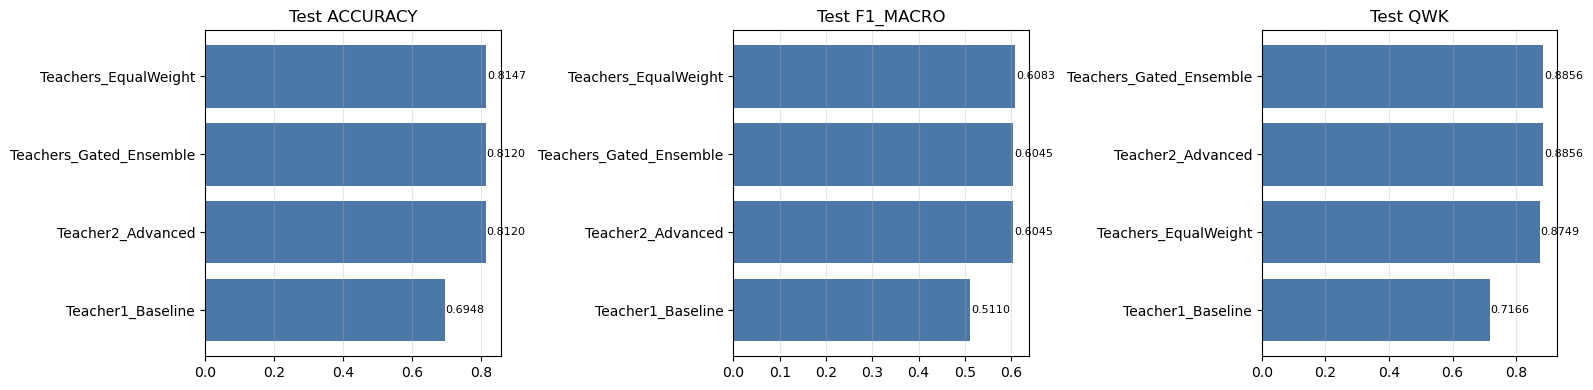

In [ ]:
# 10) Plot: Test comparison (Accuracy / F1 / QWK) - 6 scenarios
if 'results_df' in globals():
    test_df = results_df[results_df['split'] == 'test'].copy()
    if len(test_df) > 0:
        # Define colors for different model types
        color_map = {
            'Teacher1_Baseline': '#e74c3c',  # Red - weakest
            'Teacher2_Advanced': '#3498db',  # Blue - strong teacher
            'Teachers_Gated_Ensemble': '#9b59b6',  # Purple - gate1
            'Teachers_EqualWeight': '#2ecc71',  # Green - simple average
            'Teachers_Student_Gate2': '#f39c12',  # Orange - gate2
            'Teachers_Student_EqualWeight': '#1abc9c'  # Teal - student equal
        }
        
        plot_metrics = ['accuracy', 'f1_macro', 'qwk']
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle('6-Scenario Comparison: Teachers vs Teachers+Student', fontsize=14, fontweight='bold')
        
        for ax, m in zip(axes, plot_metrics):
            sdf = test_df.sort_values(m, ascending=True)
            colors = [color_map.get(model, '#95a5a6') for model in sdf['model']]
            
            bars = ax.barh(sdf['model'], sdf[m], color=colors, edgecolor='black', linewidth=0.8)
            ax.set_title(f'Test {m.upper()}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Score', fontsize=10)
            ax.grid(axis='x', alpha=0.3, linestyle='--')
            
            # Add value labels
            for i, (v, model) in enumerate(zip(sdf[m], sdf['model'])):
                label = f'{v:.4f}'
                # Highlight best score
                if v == sdf[m].max():
                    label = f'⭐ {label}'
                ax.text(v + 0.005, i, label, va='center', fontsize=9, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(RESULTS_ROOT / 'comparison_6scenarios_test_metrics.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        print('\n' + '='*100)
        print('KEY INSIGHTS:')
        print('='*100)
        test_best = test_df.sort_values('accuracy', ascending=False).iloc[0]
        print(f"🏆 Best Model: {test_best['model']}")
        print(f"   - Accuracy: {test_best['accuracy']:.4f}")
        print(f"   - F1 Macro: {test_best['f1_macro']:.4f}")
        print(f"   - QWK: {test_best['qwk']:.4f}")
        
        # Compare teacher-only vs teacher+student
        teacher_only = test_df[test_df['model'].str.contains('Teacher') & ~test_df['model'].str.contains('Student')]
        teacher_student = test_df[test_df['model'].str.contains('Student')]
        
        if len(teacher_student) > 0:
            print(f"\n📊 Teacher-Only Best: {teacher_only['accuracy'].max():.4f}")
            print(f"📊 Teacher+Student Best: {teacher_student['accuracy'].max():.4f}")
            improvement = (teacher_student['accuracy'].max() - teacher_only['accuracy'].max()) * 100
            print(f"💡 Student Contribution: +{improvement:.2f}% accuracy boost!")


## Notes

### Training Configuration
- **RUN_TRAINING=True**: Retrains teachers from scratch into RESULTS_ROOT
- **Gate1 (Teachers)**: Trains only the gate over two fixed teachers (baseline + advanced)
- **Equal-weight (Teachers)**: Uses probability averaging (no gate): `(p_base + p_adv) / 2`

### Student Model Integration
- **Teachers+Student with Gate2**: Uses pretrained checkpoint from `results/lowdata_hybrid_distill/`
  - Residual mixing: `z_final = z_teacher + α·g·(z_student - mean)`
  - Conflict brake: limits student contribution when teacher is confident
  - **No new training required** - loads existing checkpoint
  
- **Teachers+Student Equal Weight**: Simple inference-only evaluation
  - `z_final = (z_teacher + z_student) / 2`
  - No gate, no training - pure averaging
  - Helps understand raw student contribution

### 6 Scenarios Summary
1. **Teacher1 alone** - Baseline performance
2. **Teacher2 alone** - Advanced model performance
3. **Teachers + Gate1** - Learned teacher fusion
4. **Teachers Equal** - Simple teacher average
5. **Teachers+Student + Gate2** - Full model with conflict brake (from checkpoint)
6. **Teachers+Student Equal** - Simple teacher+student average (inference only)